# NumPy

In [2]:
import numpy as np


In [3]:
a=np.eye(3,2,-1)
print(np.eye(3)[[0,1,2,1]])
print(a.ndim)
print(a.shape)
print(a.size)
print(a.dtype)
print(a.itemsize)

[[1. 0. 0.]
 [0. 1. 0.]
 [0. 0. 1.]
 [0. 1. 0.]]
2
(3, 2)
6
float64
8


In [4]:
print(np.reshape(a,(2,3)))
print(a)
print(a.reshape((2,3)))
print(a)

[[0. 0. 1.]
 [0. 0. 1.]]
[[0. 0.]
 [1. 0.]
 [0. 1.]]
[[0. 0. 1.]
 [0. 0. 1.]]
[[0. 0.]
 [1. 0.]
 [0. 1.]]


a.resize和np.resize(a)不同，前者补0，后者从a的第一个元素开始复制补充

In [5]:
np.sum(a)

np.float64(2.0)

In [6]:
print(np.empty((3,5),dtype=np.float32))

[[0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 0.]]


# tensor

In [7]:
import torch

In [8]:
a=np.random.random((3,2))
print(a)
b=torch.from_numpy(a)
print(b)
c=b.numpy()
print(c)

[[0.70161013 0.92524797]
 [0.89859869 0.88418653]
 [0.43786132 0.48103789]]
tensor([[0.7016, 0.9252],
        [0.8986, 0.8842],
        [0.4379, 0.4810]], dtype=torch.float64)
[[0.70161013 0.92524797]
 [0.89859869 0.88418653]
 [0.43786132 0.48103789]]


使用from_numpy()和numpy()函数产生的tensor和NumPy数组共享
内存，对其中一个的更改也会使另一个随着改变

In [9]:
my_data1 = torch.tensor([0,1,2,3]) 
my_data2 = my_data1.reshape(-1,2)
print(my_data2)

tensor([[0, 1],
        [2, 3]])


tensor.clone()：对张量进行复制，返回一个完全相同的tensor，新张
量会保存在新的内存中，且仍然留在计算图中

In [10]:
my_data1 = torch.tensor([0,1,2,3])
print(my_data1)
my_data2 = my_data1.clone()
print(my_data2)

tensor([0, 1, 2, 3])
tensor([0, 1, 2, 3])


In [11]:
a=np.array([1,2,3,4,5,6])
print(a[1:-1:2])


[2 4]


view()共享内存

In [12]:
my_data1=torch.zeros(3,1,2,1,5)
my_data2=torch.squeeze(my_data1)#形状变为（3,2,5）
my_data3=torch.squeeze(my_data1,0)#形状变为（3,1,2,1,5）
print(my_data1.shape,my_data2.shape,my_data3.shape)

torch.Size([3, 1, 2, 1, 5]) torch.Size([3, 2, 5]) torch.Size([3, 1, 2, 1, 5])


squeeze和unsqueeze并没有修改原张量，只是看数据的维度变了。它们本质还是共享内存数据

In [13]:
my_data1=torch.tensor([-1.3,2.8,3.5,-4.2,-5.6,6.99])
my_data2=torch.add(my_data1,100) 
my_data3=my_data1.add(100) 
my_data4=my_data1.add_(100)

原位inplace，add_是原地修改，其余返回新张量。numpy没有add_，可以参数out指定

In [14]:
my_data2=torch.tensor([[1,2,3]])
print(my_data2.shape)
my_data2=torch.tensor([[[1],[2],[3]],[[4],[5],[6]]])
print(my_data2.shape)

torch.Size([1, 3])
torch.Size([2, 3, 1])


需要广播的复制补充是逻辑上的，真实数据没变，利用原数据计算，所以原位操作会报错，广播并未修改。

# PIL

In [15]:
import PIL
from PIL import Image
import torchvision.transforms as transforms


PIL的读取格式（W，H，C）,通过transforms.ToTensor（）转换(C,H,W)

Image.open(filename).covert('RGB')

# OpenCV

In [16]:
import cv2 

cv2.imread(filename)是np.array

cv2读取BGR格式，使用cv2.cvtColor(,cv2.COLOR_BGR2RGB)转换

# torchvison.io

In [17]:
import torchvision.io

torchvision.io.read_image(path,mode)：读入JPEG或PNG格式的图像，并保存为3维RGB或灰度张量，返回输出张量outputtensor[channel,height,width],数据格式uint8，值范围[0,255]

# matplotlib

In [18]:
import matplotlib.pyplot as plt

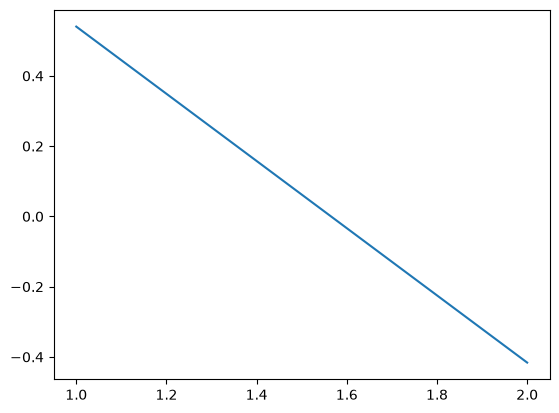

In [19]:
x = np.array([1,2]) 
y= np.cos(x) 
plt.plot(x,y)

# 神经网络构建

In [20]:
import torch.nn as nn

参数可以通过Parameter产生，但是pytorch要注册到模块，可以self.注册也可以self.register_parameter(name,)注册

In [ ]:
class module_t(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv=nn.Conv2d(3,64,kernel_size=3,stride=1)
        self.weight=nn.Parameter(torch.randn((2,2)))
        w=nn.Parameter(torch.randn((2,2)))
        self.register_parameter('w',w)
    
    def forward1(self,x):
        return nn.functional.relu(self.conv(x))
    
    def forward1(self,x):
        return x.mm(self.weight) #torch.nn  矩阵乘

# 预训练

In [ ]:
from torchvision import models

In [ ]:
import torchvision.models as models
#仅加载网络结构，不需要加载预训练模型参数
my_model1= models.vgg19()
#加载网络结构，同时加载一种权重
my_model2=models.vgg19(weights=models.VGG19_Weights.IMAGENET1K_V1)#加载网络结构，同时加载当前最优权重
my_model2=models.vgg19(weights=models.VGG19_Weights.DEFAULT)